# Detección de Objetos con PyTorch

Este laboratorio está adaptado del curso [Microsoft AI for Beginners](http://aka.ms/ai-beginners), reescrito en **PyTorch** (el original usa TensorFlow/Keras).

![Algoritmos de visión por computador](https://cdn-images-1.medium.com/max/840/1*Hz6t-tokG1niaUfmcysusw.jpeg)

## Enfoque ingenuo para la detección de objetos

* Dividir la imagen en recuadros (*tiles*)
* Pasar cada recuadro por un clasificador de imágenes basado en una CNN
* Seleccionar los recuadros cuya activación supere un umbral

In [1]:
import os
import urllib.request

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


Leamos una imagen de ejemplo con la que trabajar y rellenémosla (*padding*) para que sea cuadrada:

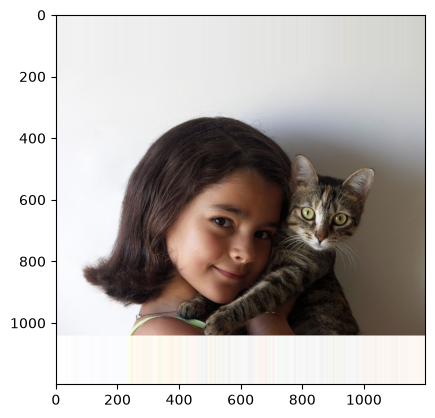

In [2]:
img_path = 'images/1200px-Girl_and_cat.jpg'
if not os.path.exists(img_path):
    os.makedirs('images', exist_ok=True)
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/microsoft/AI-For-Beginners/main/'
        'lessons/4-ComputerVision/11-ObjectDetection/images/1200px-Girl_and_cat.jpg',
        img_path)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = np.pad(img, ((158, 158), (0, 0), (0, 0)), mode='edge')
plt.imshow(img)

Usaremos la CNN **VGG-16** preentrenada en ImageNet que provee `torchvision`:

In [3]:
weights = models.VGG16_Weights.IMAGENET1K_V1
vgg = models.vgg16(weights=weights).to(device).eval()

Definamos una función que prediga la probabilidad de que haya un gato en la imagen. Como ImageNet contiene varias clases de gatos, con índices del 281 al 294, simplemente sumaremos las probabilidades de esas clases para obtener una probabilidad global de 'gato'.

A diferencia de Keras, en PyTorch debemos preparar la entrada a mano: redimensionar a 224×224, escalar a $[0,1]$, normalizar con la media y desviación estándar de ImageNet, y reordenar los ejes de `(H, W, C)` a `(C, H, W)`. Además, VGG-16 de `torchvision` entrega *logits*, por lo que aplicamos `softmax` para obtener probabilidades.

In [4]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess(img):
    im = cv2.resize(img, (224, 224)).astype(np.float32) / 255.0
    im = (im - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(im).permute(2, 0, 1)   # (H,W,C) -> (C,H,W)

@torch.no_grad()
def predict(img):
    x = preprocess(img).unsqueeze(0).to(device)    # agregamos la dimensión del batch
    pr = F.softmax(vgg(x), dim=1)[0].cpu().numpy()
    return np.sum(pr[281:294])  # sabemos que las clases de gatos en VGG van de la 281 a la 294

predict(img)

np.float32(0.9057945)

La siguiente función construye un mapa de calor (*heatmap*) de probabilidades, dividiendo la imagen en $n\times n$ cuadrados. En lugar de llamar a la red una vez por recuadro, apilamos los $n^2$ recuadros en un solo *batch*, lo que es mucho más eficiente (sobre todo en GPU):

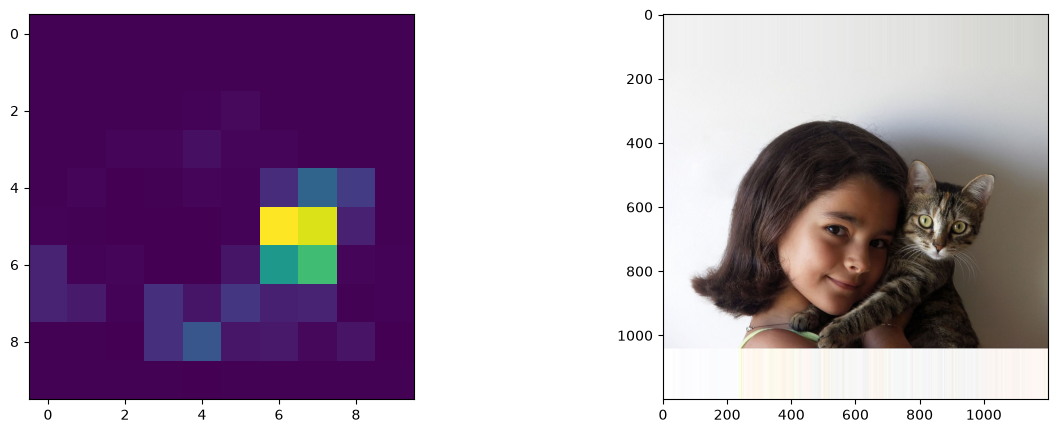

In [5]:
@torch.no_grad()
def predict_map(img, n):
    dx = img.shape[0] // n
    tiles = [preprocess(img[dx*i:dx*(i+1), dx*j:dx*(j+1)])
             for i in range(n) for j in range(n)]
    x = torch.stack(tiles).to(device)
    pr = F.softmax(vgg(x), dim=1).cpu().numpy()
    return pr[:, 281:294].sum(axis=1).reshape(n, n)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[1].imshow(img)
ax[0].imshow(predict_map(img, 10))

## Detección de objetos simples

Para entregar una ubicación más precisa del recuadro delimitador (*bounding box*), necesitamos un **modelo de regresión** que prediga sus coordenadas. Partamos con un ejemplo sencillo: imágenes de 8×8 que contienen un rectángulo, el cual queremos detectar. La idea y parte del código provienen de [este artículo](https://towardsdatascience.com/object-detection-with-neural-networks-a4e2c46b4491).

La siguiente función genera un conjunto de imágenes de ejemplo:

In [6]:
np.random.seed(42)
torch.manual_seed(42)

def generate_images(num_imgs, img_size=8, min_object_size=1, max_object_size=4):
    bboxes = np.zeros((num_imgs, 4))
    imgs = np.zeros((num_imgs, img_size, img_size))  # fondo en 0

    for i_img in range(num_imgs):
        w, h = np.random.randint(min_object_size, max_object_size, size=2)
        x = np.random.randint(0, img_size - w)
        y = np.random.randint(0, img_size - h)
        imgs[i_img, x:x+w, y:y+h] = 1.  # rectángulo en 1
        bboxes[i_img] = [x, y, w, h]
    return imgs, bboxes

imgs, bboxes = generate_images(100000)
print(f"Forma de las imágenes = {imgs.shape}")
print(f"Forma de los bboxes   = {bboxes.shape}")

Forma de las imágenes = (100000, 8, 8)
Forma de los bboxes   = (100000, 4)


Para que las salidas de la red queden en el rango $[0;1]$, dividiremos `bboxes` por el tamaño de la imagen:

In [7]:
bb = bboxes / 8.0
bb[0]

array([0.25 , 0.5  , 0.375, 0.125])

En este ejemplo sencillo usaremos una red neuronal densa (*fully connected*). En la práctica, cuando los objetos tienen formas más complejas, tiene mucho más sentido usar CNNs para este tipo de tarea. Usaremos el optimizador de descenso de gradiente estocástico (SGD) y el error cuadrático medio (MSE) como función de pérdida, ya que nuestra tarea es de **regresión**.

In [8]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(8*8, 200),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(200, 4)
).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

print(model)
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=64, out_features=200, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=200, out_features=4, bias=True)
)
Parámetros entrenables: 13,804


Entrenemos la red. También normalizaremos los datos de entrada (restando la media y dividiendo por la desviación estándar) para obtener un desempeño algo mejor.

En PyTorch escribimos el ciclo de entrenamiento explícitamente: un `DataLoader` entrega *mini-batches* de 32 ejemplos y, para cada uno, calculamos la pérdida, propagamos el gradiente hacia atrás y actualizamos los pesos.

In [9]:
from torch.utils.data import TensorDataset, DataLoader

imgs_mean, imgs_std = np.mean(imgs), np.std(imgs)
imgs_norm = (imgs - imgs_mean) / imgs_std

dataset = TensorDataset(torch.tensor(imgs_norm, dtype=torch.float32),
                        torch.tensor(bb, dtype=torch.float32))
loader = DataLoader(dataset, batch_size=32, shuffle=True)

epochs = 30
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    print(f"Época {epoch+1}/{epochs} - pérdida: {total_loss/len(dataset):.4f}")

Época 1/30 - pérdida: 0.0174


Época 2/30 - pérdida: 0.0080


Época 3/30 - pérdida: 0.0063


Época 4/30 - pérdida: 0.0055


Época 5/30 - pérdida: 0.0050


...

Época 26/30 - pérdida: 0.0023


Época 27/30 - pérdida: 0.0022


Época 28/30 - pérdida: 0.0022


Época 29/30 - pérdida: 0.0022


Época 30/30 - pérdida: 0.0021


Parece que obtuvimos una pérdida relativamente baja; veamos cómo se traduce en métricas más tangibles, como el mAP. Primero, definamos la métrica IoU (*Intersection over Union*) entre dos recuadros delimitadores:

In [10]:
def IOU(bbox1, bbox2):
    '''Calcula el traslape entre dos recuadros [x, y, w, h] como el área de la intersección sobre el área de la unión'''
    x1, y1, w1, h1 = bbox1[0], bbox1[1], bbox1[2], bbox1[3]
    x2, y2, w2, h2 = bbox2[0], bbox2[1], bbox2[2], bbox2[3]
    w_I = min(x1 + w1, x2 + w2) - max(x1, x2)
    h_I = min(y1 + h1, y2 + h2) - max(y1, y2)
    if w_I <= 0 or h_I <= 0:  # no hay traslape
        return 0.
    I = w_I * h_I
    U = w1 * h1 + w2 * h2 - I
    return I / U

Ahora generaremos 500 imágenes de prueba y graficaremos las primeras 5 para visualizar qué tan precisos somos. También imprimiremos la métrica IoU. El recuadro predicho se dibuja en rojo y el real en verde.

Notar que el modelo debe pasar a modo evaluación con `model.eval()` (desactiva el *dropout*) y que las imágenes de prueba se normalizan con la media y desviación estándar **del conjunto de entrenamiento**.

pred=[2.318995  1.7224263 1.080049  1.429712 ], real=[2. 1. 1. 1.], IoU=0.080
pred=[1.0217774  0.00870943 1.9757206  2.939942  ], real=[1. 0. 2. 3.], IoU=0.968
pred=[5.0934725  0.94204915 1.0187312  2.6880984 ], real=[5. 1. 1. 3.], IoU=0.711
pred=[4.9717674 3.0601916 0.974642  2.695241 ], real=[5. 3. 1. 3.], IoU=0.829
pred=[1.0428644 2.4193804 1.1814251 1.1908091], real=[0. 2. 1. 1.], IoU=0.000


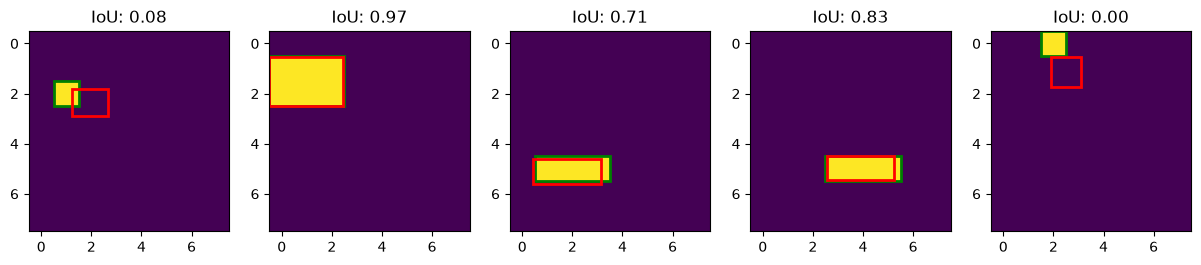

In [11]:
test_imgs, test_bboxes = generate_images(500)

model.eval()
with torch.no_grad():
    x_test = torch.tensor((test_imgs - imgs_mean) / imgs_std, dtype=torch.float32).to(device)
    bb_res = model(x_test).cpu().numpy() * 8

# En imshow el pixel (fila, col) ocupa [col-0.5, col+0.5]; x = fila, y = columna
def draw_bbox(b, color):
    plt.gca().add_patch(matplotlib.patches.Rectangle(
        (b[1] - 0.5, b[0] - 0.5), b[3], b[2], ec=color, fill=False, lw=2))

plt.figure(figsize=(15, 5))
for i in range(5):
    print(f"pred={bb_res[i]}, real={test_bboxes[i]}, IoU={IOU(bb_res[i], test_bboxes[i]):.3f}")
    plt.subplot(1, 5, i+1)
    plt.imshow(test_imgs[i])
    draw_bbox(test_bboxes[i], 'g')
    draw_bbox(bb_res[i], 'r')
    plt.title(f"IoU: {IOU(bb_res[i], test_bboxes[i]):.2f}")

Para calcular la precisión media sobre todos los casos, basta con recorrer todas las muestras de prueba, calcular el IoU y promediar:

In [12]:
np.array([IOU(a, b) for a, b in zip(test_bboxes, bb_res)]).mean()

np.float64(0.6994354859740565)

## Detección de objetos en la vida real

Los detectores reales son bastante más complejos que nuestra red densa: deben encontrar un número **variable** de objetos de **varias clases**, en imágenes de tamaño arbitrario. **Faster R-CNN** resuelve esto en dos etapas:

1. Una **Region Proposal Network (RPN)** propone regiones candidatas (*anchors* ajustados) sobre el mapa de características de una CNN (*backbone*, aquí ResNet-50 con FPN).
2. Una **cabeza de clasificación y regresión** (*RoI head*) clasifica cada región y refina las coordenadas de su recuadro, tal como hicimos arriba con la regresión.

Esta sección sigue el [tutorial oficial de PyTorch *TorchVision Object Detection Finetuning*](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html): tomaremos un Faster R-CNN preentrenado en COCO y lo ajustaremos (*fine-tuning*) para detectar peatones en el conjunto **Penn-Fudan**. A diferencia del tutorial, nos quedamos solo con la detección (sin segmentación de instancias) y escribimos el ciclo de entrenamiento y una evaluación simple a mano, sin depender de sus archivos auxiliares (`engine.py`, `utils.py`, `pycocotools`).

> ⚠️ El entrenamiento es pesado: en GPU toma un par de minutos, en CPU puede tardar 15–30 minutos.

### Un detector preentrenado listo para usar

Antes de entrenar nada, veamos qué hace un detector preentrenado en COCO (80 clases) sobre nuestra imagen de la niña y el gato. Cada predicción es un diccionario con `boxes` (en formato `[x1, y1, x2, y2]`, a diferencia del `[x, y, w, h]` de arriba), `labels` y `scores`.

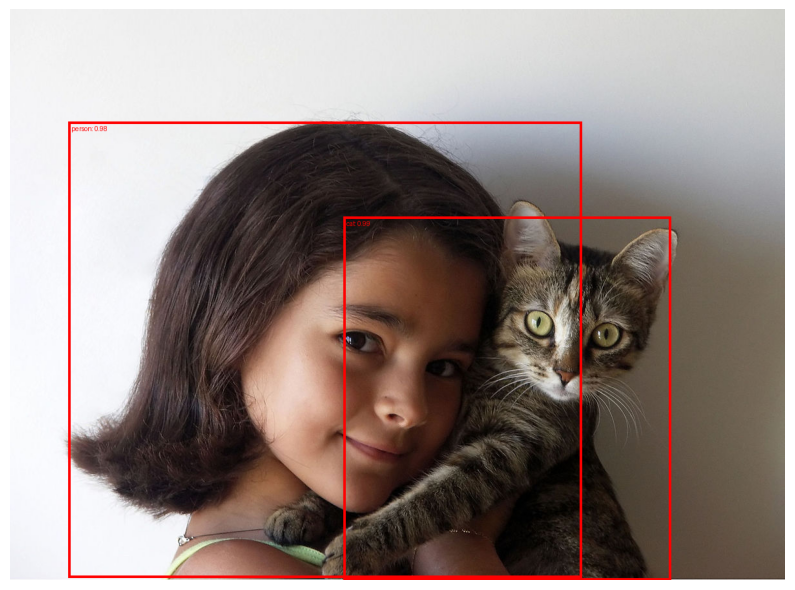

In [13]:
import zipfile
from torchvision.io import read_image, ImageReadMode
from torchvision.ops import masks_to_boxes, box_iou
from torchvision import tv_tensors
from torchvision.transforms import v2 as T
from torchvision.utils import draw_bounding_boxes
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

coco_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
coco_classes = coco_weights.meta['categories']
coco_model = fasterrcnn_resnet50_fpn(weights=coco_weights).to(device).eval()

cat_img = read_image(img_path, ImageReadMode.RGB)       # tensor uint8 (C,H,W)
with torch.no_grad():
    pred = coco_model([(cat_img.float() / 255).to(device)])[0]

keep = pred['scores'] > 0.7
labels = [f"{coco_classes[l]}: {s:.2f}" for l, s in zip(pred['labels'][keep], pred['scores'][keep])]
out = draw_bounding_boxes(cat_img, pred['boxes'][keep].cpu(), labels, colors='red', width=4)
plt.figure(figsize=(10, 10))
plt.imshow(out.permute(1, 2, 0))
plt.axis("off");

### El conjunto de datos Penn-Fudan

Contiene 170 imágenes con 345 peatones. Las anotaciones vienen como máscaras en las que cada peatón está codificado con un valor distinto (0 es el fondo); de ellas obtendremos los recuadros. Descarguémoslo:

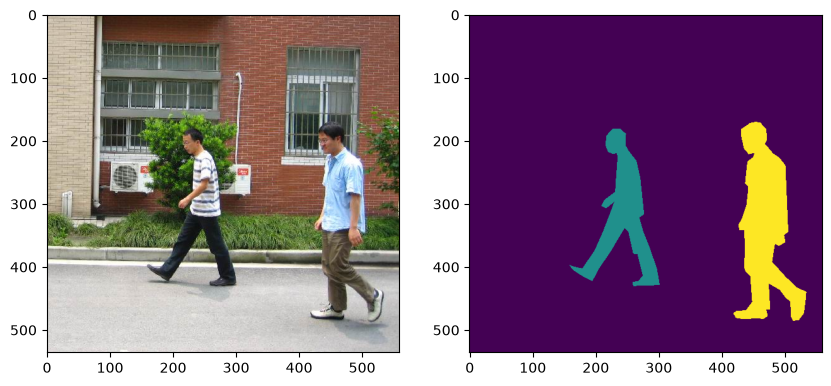

In [14]:
data_root = 'data/PennFudanPed'
if not os.path.exists(data_root):
    os.makedirs('data', exist_ok=True)
    urllib.request.urlretrieve('https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip',
                               'data/PennFudanPed.zip')
    with zipfile.ZipFile('data/PennFudanPed.zip') as z:
        z.extractall('data')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(read_image(f'{data_root}/PNGImages/FudanPed00001.png').permute(1, 2, 0))
ax[1].imshow(read_image(f'{data_root}/PedMasks/FudanPed00001_mask.png')[0])

Definimos un `Dataset` de PyTorch. Los modelos de detección de `torchvision` esperan, para cada imagen, un diccionario `target` con:

* `boxes`: tensor `(N, 4)` con los recuadros en formato `[x1, y1, x2, y2]`
* `labels`: tensor `(N,)` con la clase de cada objeto (0 está reservado para el fondo, así que los peatones son la clase 1)

Los recuadros se obtienen de las máscaras con `masks_to_boxes`. Envolver la imagen y los recuadros en `tv_tensors` permite que las transformaciones `v2` (por ejemplo, el volteo horizontal) se apliquen de forma consistente a la imagen y a sus recuadros.

In [15]:
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # ordenamos para que imágenes y máscaras queden alineadas
        self.imgs = sorted(os.listdir(os.path.join(root, 'PNGImages')))
        self.masks = sorted(os.listdir(os.path.join(root, 'PedMasks')))

    def __getitem__(self, idx):
        img = read_image(os.path.join(self.root, 'PNGImages', self.imgs[idx]), ImageReadMode.RGB)
        mask = read_image(os.path.join(self.root, 'PedMasks', self.masks[idx]))
        # cada instancia está codificada con un valor distinto; el primero (0) es el fondo
        obj_ids = torch.unique(mask)[1:]
        # una máscara binaria por instancia -> un recuadro por instancia
        boxes = masks_to_boxes(mask == obj_ids[:, None, None])

        img = tv_tensors.Image(img)
        target = {
            'boxes': tv_tensors.BoundingBoxes(boxes, format='XYXY', canvas_size=img.shape[-2:]),
            'labels': torch.ones((len(obj_ids),), dtype=torch.int64),   # una sola clase: peatón
        }
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.imgs)

def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))   # aumento de datos
    transforms.append(T.ToDtype(torch.float, scale=True))  # uint8 [0,255] -> float [0,1]
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

### Adaptando el modelo a nuestras clases

Partimos del Faster R-CNN preentrenado en COCO y **reemplazamos solo la cabeza** de predicción de recuadros por una nueva con `num_classes = 2` (fondo + peatón). El *backbone* y la RPN conservan lo aprendido en COCO: esto es *transfer learning*, igual que en el laboratorio de clasificación.

In [16]:
def get_detection_model(num_classes):
    model = fasterrcnn_resnet50_fpn(weights=coco_weights)
    # nueva cabeza de clasificación/regresión de recuadros
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

Separamos 50 imágenes para prueba. Como cada imagen tiene un tamaño y un número de objetos distintos, no podemos apilarlas en un solo tensor: la función `collate_fn` simplemente devuelve tuplas de imágenes y de *targets*.

In [17]:
torch.manual_seed(1)
dataset_train = PennFudanDataset(data_root, get_transform(train=True))
dataset_test = PennFudanDataset(data_root, get_transform(train=False))

indices = torch.randperm(len(dataset_train)).tolist()
dataset_train = torch.utils.data.Subset(dataset_train, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

def collate_fn(batch):
    return tuple(zip(*batch))

loader_train = DataLoader(dataset_train, batch_size=2, shuffle=True, collate_fn=collate_fn)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False, collate_fn=collate_fn)
print(f"Entrenamiento: {len(dataset_train)} imágenes, prueba: {len(dataset_test)} imágenes")

Entrenamiento: 120 imágenes, prueba: 50 imágenes


### Entrenamiento

En modo entrenamiento, los modelos de detección de `torchvision` reciben las imágenes **y** los *targets*, y devuelven directamente un diccionario de pérdidas: clasificación y regresión de la RPN (`loss_objectness`, `loss_rpn_box_reg`) y clasificación y regresión de la cabeza final (`loss_classifier`, `loss_box_reg`). Las sumamos y optimizamos con SGD con *momentum*, reduciendo la tasa de aprendizaje cada 3 épocas. Con solo 2 épocas basta para obtener buenos resultados gracias al preentrenamiento.

In [18]:
det_model = get_detection_model(num_classes=2).to(device)

params = [p for p in det_model.parameters() if p.requires_grad]
det_optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(det_optimizer, step_size=3, gamma=0.1)

num_epochs = 2
for epoch in range(num_epochs):
    det_model.train()
    for it, (images, targets) in enumerate(loader_train):
        images = [im.to(device) for im in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = det_model(images, targets)
        losses = sum(loss_dict.values())

        det_optimizer.zero_grad()
        losses.backward()
        det_optimizer.step()

        if it % 10 == 0:
            detalle = ', '.join(f"{k}: {v.item():.3f}" for k, v in loss_dict.items())
            print(f"Época {epoch} [{it}/{len(loader_train)}] pérdida: {losses.item():.3f} ({detalle})")
    lr_scheduler.step()

Época 0 [0/60] pérdida: 1.312 (loss_classifier: 0.743, loss_box_reg: 0.485, loss_objectness: 0.068, loss_rpn_box_reg: 0.016)


Época 0 [10/60] pérdida: 0.312 (loss_classifier: 0.075, loss_box_reg: 0.226, loss_objectness: 0.004, loss_rpn_box_reg: 0.007)


Época 0 [20/60] pérdida: 0.273 (loss_classifier: 0.042, loss_box_reg: 0.216, loss_objectness: 0.003, loss_rpn_box_reg: 0.012)


Época 0 [30/60] pérdida: 0.060 (loss_classifier: 0.018, loss_box_reg: 0.040, loss_objectness: 0.000, loss_rpn_box_reg: 0.001)


Época 0 [40/60] pérdida: 0.340 (loss_classifier: 0.103, loss_box_reg: 0.218, loss_objectness: 0.005, loss_rpn_box_reg: 0.014)


...

Época 1 [10/60] pérdida: 0.127 (loss_classifier: 0.047, loss_box_reg: 0.072, loss_objectness: 0.002, loss_rpn_box_reg: 0.004)


Época 1 [20/60] pérdida: 0.254 (loss_classifier: 0.069, loss_box_reg: 0.170, loss_objectness: 0.006, loss_rpn_box_reg: 0.009)


Época 1 [30/60] pérdida: 0.132 (loss_classifier: 0.038, loss_box_reg: 0.085, loss_objectness: 0.003, loss_rpn_box_reg: 0.006)


Época 1 [40/60] pérdida: 0.302 (loss_classifier: 0.097, loss_box_reg: 0.191, loss_objectness: 0.004, loss_rpn_box_reg: 0.010)


Época 1 [50/60] pérdida: 0.110 (loss_classifier: 0.024, loss_box_reg: 0.082, loss_objectness: 0.000, loss_rpn_box_reg: 0.004)


### Evaluación

El tutorial usa las métricas oficiales de COCO (mAP promediado sobre umbrales de IoU de 0.5 a 0.95). Aquí haremos una evaluación más simple, que reutiliza la idea de IoU que vimos antes: una predicción con confianza > 0.5 es un **verdadero positivo** si tiene IoU ≥ 0.5 con algún peatón real aún no asignado. Con eso calculamos **precisión**, **exhaustividad** (*recall*) y el IoU medio de los aciertos. `box_iou` de `torchvision` calcula la matriz de IoU entre todos los pares de recuadros `[x1, y1, x2, y2]`.

In [19]:
@torch.no_grad()
def evaluate_detector(model, loader, score_thr=0.5, iou_thr=0.5):
    model.eval()
    tp = n_pred = n_gt = 0
    ious = []
    for images, targets in loader:
        preds = model([im.to(device) for im in images])
        for p, t in zip(preds, targets):
            boxes = p['boxes'][p['scores'] > score_thr].cpu()   # ya vienen ordenadas por score
            gt = t['boxes']
            n_pred += len(boxes)
            n_gt += len(gt)
            if len(boxes) == 0 or len(gt) == 0:
                continue
            iou = box_iou(boxes, gt)
            for i in range(len(boxes)):            # asignación voraz
                best, j = iou[i].max(0)
                if best >= iou_thr:
                    tp += 1
                    ious.append(best.item())
                    iou[:, j] = 0                  # cada peatón real se asigna una sola vez
    print(f"Precisión: {tp/max(n_pred,1):.3f}  Recall: {tp/max(n_gt,1):.3f}  IoU medio de aciertos: {np.mean(ious):.3f}")

evaluate_detector(det_model, loader_test)

Precisión: 0.799  Recall: 1.000  IoU medio de aciertos: 0.860


### Inferencia sobre una imagen de prueba

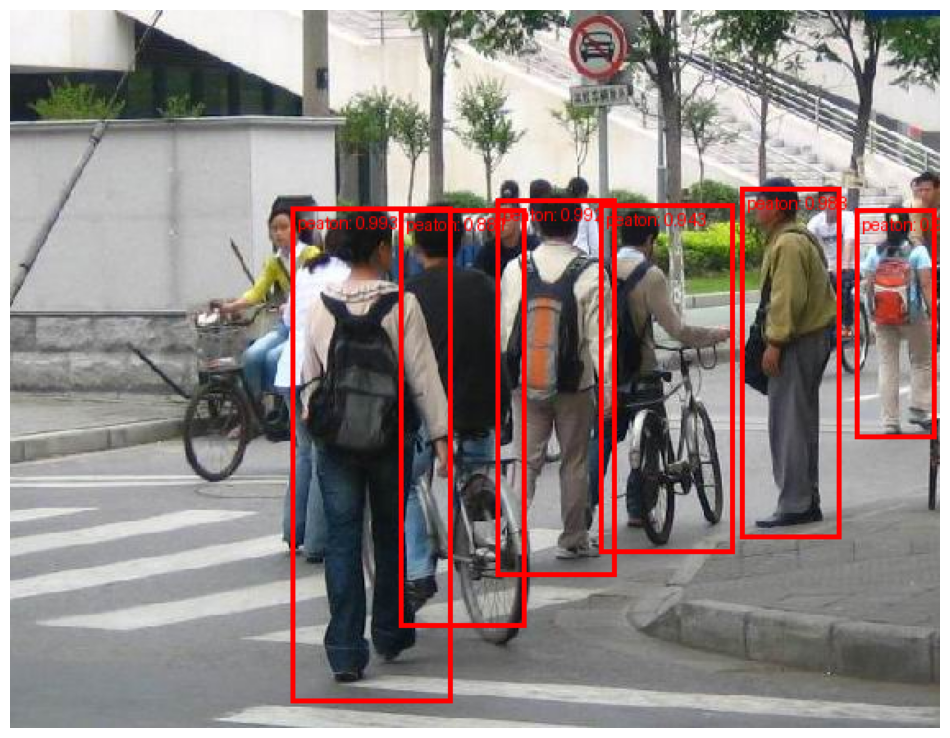

In [20]:
image = read_image(f'{data_root}/PNGImages/FudanPed00046.png', ImageReadMode.RGB)
eval_transform = get_transform(train=False)

det_model.eval()
with torch.no_grad():
    pred = det_model([eval_transform(image).to(device)])[0]

keep = pred['scores'] > 0.5
pred_labels = [f"peaton: {s:.3f}" for s in pred['scores'][keep]]   # la fuente por defecto de draw_bounding_boxes no tiene tildes
output_image = draw_bounding_boxes(image, pred['boxes'][keep].long().cpu(), pred_labels, colors='red', width=3)

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off");

### Para seguir explorando

* El [tutorial original](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html) muestra cómo usar un *backbone* distinto (por ejemplo MobileNetV2) y cómo evaluar con las métricas COCO.
* `torchvision.models.detection` ofrece otros detectores listos para usar: RetinaNet, SSD y FCOS.
* La biblioteca [Ultralytics YOLO](https://docs.ultralytics.com/) permite entrenar detectores de una etapa (YOLO) con muy pocas líneas de código.